In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("Student_Performance.csv")

In [3]:
data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23
9996,7,64,Yes,8,5,58
9997,6,83,Yes,8,5,74
9998,9,97,Yes,7,0,95


In [4]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [6]:
data.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [9]:
data["Extracurricular Activities"]=data["Extracurricular Activities"].apply(lambda x: 1 if x =="Yes" else 0)

In [10]:
data 

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66
...,...,...,...,...,...,...
9995,1,49,1,4,2,23
9996,7,64,1,8,5,58
9997,6,83,1,8,5,74
9998,9,97,1,7,0,95


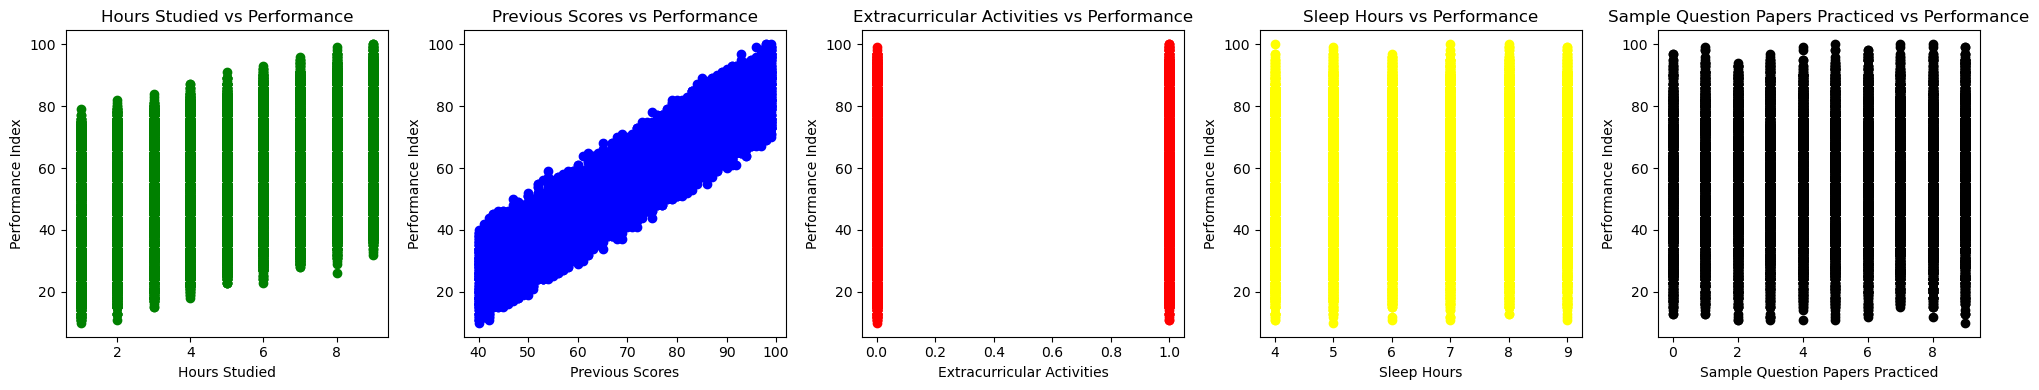

In [12]:
features = ["Hours Studied", "Previous Scores", "Extracurricular Activities", "Sleep Hours", "Sample Question Papers Practiced"]
colors = ["green", "blue", "red", "yellow", "black"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, feature in enumerate(features):
    axes[i].scatter(data[feature], data["Performance Index"], color=colors[i])
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Performance Index")
    axes[i].set_title(f"{feature} vs Performance")

plt.tight_layout()
plt.show()

In [15]:
data.corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular Activities,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


In [16]:
x = data.drop(["Performance Index"],axis=1)
y = data[["Performance Index"]]

In [17]:
x

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [18]:
y

,Performance Index
0,91
1,65
2,45
3,36
4,66
...,...
9995,23
9996,58
9997,74
9998,95


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.30,random_state=42)

In [23]:
y_train.shape

(7000, 1)

In [24]:
y_test.shape

(3000, 1)

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
mlr = LinearRegression()

In [27]:
mlr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
mlr.coef_

array([[2.85895223, 1.01551979, 0.58171285, 0.47967676, 0.19039416]])

In [29]:
mlr.intercept_

array([-33.83654381])

In [30]:
y_train_pred = mlr.predict(x_train)

In [31]:
y_train_pred

array([[81.78589232],
       [80.18393722],
       [49.98815703],
       ...,
       [45.13907865],
       [21.06892959],
       [22.61569669]], shape=(7000, 1))

In [39]:
from sklearn.metrics import r2_score,root_mean_squared_error

In [41]:
root_mean_squared_error(y_train,y_train_pred)

2.0477972830427564

In [42]:
r2_score(y_train,y_train_pred)

0.9886221887978632

In [43]:
y_test_predict = mlr.predict(x_test)

In [44]:
y_test_predict

array([[54.74728554],
       [22.61884434],
       [47.93665124],
       ...,
       [33.42451751],
       [67.92578967],
       [31.20587077]], shape=(3000, 1))

In [45]:
root_mean_squared_error(y_test,y_test_predict)

2.016572295776343

In [46]:
r2_score(y_test,y_test_predict)

0.9890110607021136

In [47]:
def predict_performance(data):
    return mlr.predict(data)

In [48]:
predict_performance([[8, 51, 1, 7, 2]])

C:\Users\hp\Downloads\apps\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[45.14682203]])

In [50]:
Hours_Studied = int(input("Enter your hours of studies:"))	
Previous_Scores = int(input("Enter your previous scores:"))	
Extracurricular_Activities = int(input("Enter your extracurricular activities (Yes=1/No=1):"))
Sleep_Hours	= int(input("Enter your sleep hours:"))	
Sample_Question_Papers_Practiced = int(input("Enter sample question practiced:"))
predict_performance([[Hours_Studied, Previous_Scores, Extracurricular_Activities, Sleep_Hours, Sample_Question_Papers_Practiced]])

Enter your hours of studies: 8
Enter your previous scores: 51
Enter your extracurricular activities (Yes=1/No=1): 1
Enter your sleep hours: 7
Enter sample question practiced: 2


C:\Users\hp\Downloads\apps\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[45.14682203]])